## Stage 2 EDA (Business Hypotheses)

EDA notebook for Stage 2 outputs with seaborn visualizations.

- Inputs: `output/q1.csv` ... `output/q5.csv`
- Purpose: quick interpretation of business hypotheses
- Pipeline dependency: none (analysis-only notebook)

### How to run

1. Execute all cells from top to bottom.
2. Ensure Stage 2 has already generated `output/q1.csv` ... `output/q5.csv`.
3. Re-run after each Stage 2 refresh to update plots.

In [15]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.max_columns", 50)

In [16]:
# Resolve output directory for both launch modes:
# 1) notebook opened from repo root, 2) notebook opened from notebooks/ folder
candidates = [Path("output"), Path("../output")]
output_dir = next((p for p in candidates if p.exists()), None)
if output_dir is None:
    raise FileNotFoundError("Could not locate output directory with q1..q5.csv")

file_map = {
    "q1": output_dir / "q1.csv",
    "q2": output_dir / "q2.csv",
    "q3": output_dir / "q3.csv",
    "q4": output_dir / "q4.csv",
    "q5": output_dir / "q5.csv",
}

for name, path in file_map.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

# q*.csv headers are exported as fully-qualified Hive aliases (e.g. q1_results.avg_rating)
# Normalize to clean column names for easier plotting.
def load_query_csv(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path)
    frame.columns = [c.split(".")[-1] for c in frame.columns]
    return frame

q1 = load_query_csv(file_map["q1"])
q2 = load_query_csv(file_map["q2"])
q3 = load_query_csv(file_map["q3"])
q4 = load_query_csv(file_map["q4"])
q5 = load_query_csv(file_map["q5"])

print("Loaded files from:", output_dir.resolve())
display(q1.head(3))
display(q2.head(3))
display(q3.head(3))
display(q4.head(3))
display(q5.head(3))

Loaded files from: C:\Users\Maksim\Desktop\IBD\project\amazon-reviews-bigdata\output


,main_category,purchase_type,review_count,avg_rating,avg_helpful_vote,low_rating_share
0,AMAZON FASHION,verified,1025,4.1980,0.5083,0.1532
1,All Beauty,verified,633,4.3712,0.3254,0.1201
2,All Electronics,verified,2389,4.4232,1.0762,0.1118


,review_year,review_month,review_count,avg_rating,low_rating_share,verified_purchase_ratio,avg_helpful_vote
0,2000,10,1,4.0,0.0,0.0,2.0
1,2002,11,1,5.0,0.0,1.0,11.0
2,2003,1,1,5.0,0.0,0.0,4.0


,store,review_count,avg_rating,low_rating_share,avg_helpful_vote,verified_purchase_ratio
0,WAQIA,233,2.5236,0.5966,4.1202,0.9957
1,Quirky,499,2.5952,0.5551,18.3327,0.7234
2,Aqua Plumb,694,2.5965,0.5447,0.3890,0.9798


,price_band,review_count,avg_rating,low_rating_share,avg_helpful_vote
0,0_25,851510,4.3055,0.1354,0.5184
1,unknown,522690,4.0751,0.1874,1.3373
2,25_75,500803,4.3234,0.1344,0.6471


,main_category,review_count,low_rating_count,low_rating_share,low_rating_helpful_votes,avg_helpful_on_low_ratings
0,Appliances,582120,106395,0.1828,288867,2.7150
1,Tools & Home Improvement,771841,104268,0.1351,107198,1.0281
2,Amazon Home,575362,85381,0.1484,103581,1.2132


### Q1. Verified vs Non-Verified Purchases by Category

**How to read the charts**

- **Heatmap**: each **row** is a `main_category` (the top 12 categories by total `review_count` in this slice; `unknown` is excluded). Each **column** is `purchase_type`: **verified** (Amazon recorded a purchase) vs **not_verified**.
- **Left heatmap (colour)** encodes **`avg_rating`**: the mean star rating on the usual **1–5** scale. Darker blue means a higher average rating for that category and purchase type.
- **Right heatmap (colour)** encodes **`low_rating_share`**: the fraction of reviews with rating **≤ 2** in that cell (see SQL definition below). Darker red means a larger share of strongly negative reviews.

**Metric definition (`low_rating_share`)**

Computed in SQL as `AVG(CASE WHEN rating <= 2 THEN 1.0 ELSE 0.0 END)` — i.e. the proportion of 1–2 star reviews, not the full star distribution. Use it as a **risk / dissatisfaction** indicator alongside `avg_rating`.


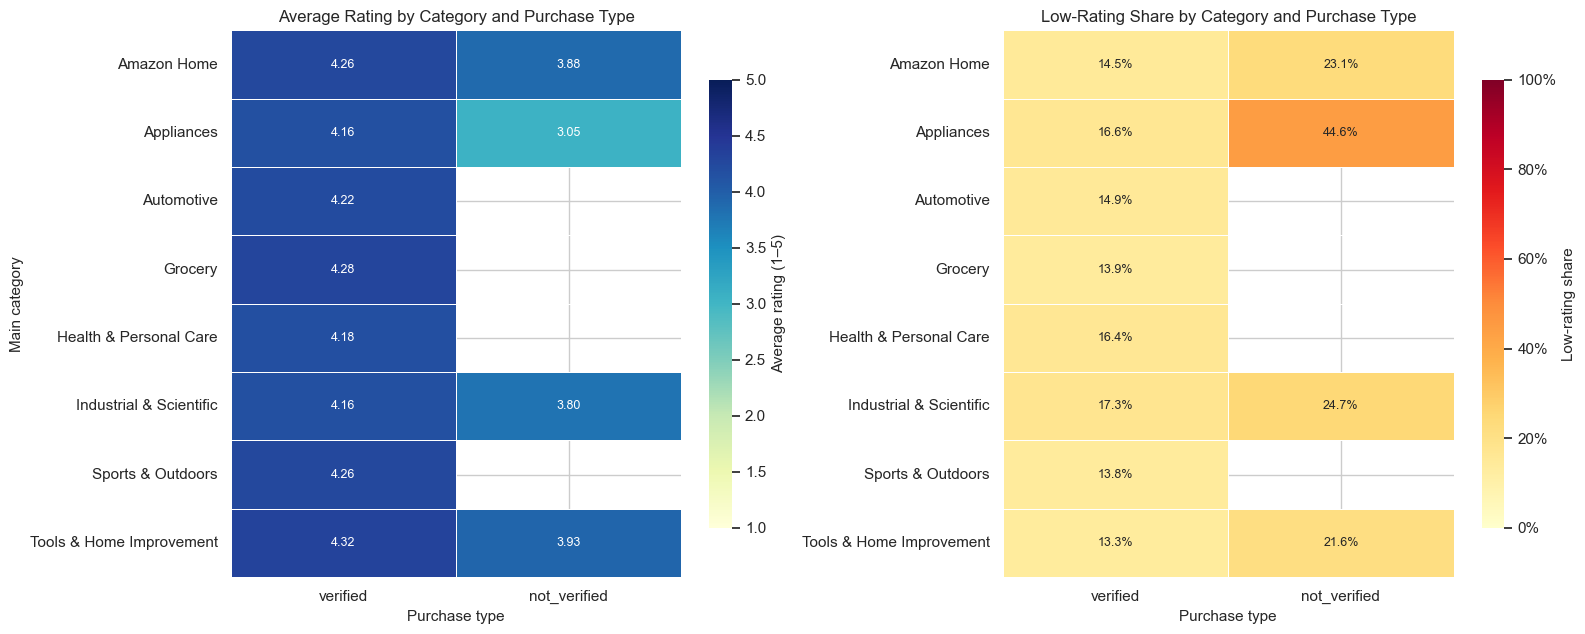

In [17]:
q1_plot = q1.copy()
q1_plot = q1_plot[q1_plot["main_category"].ne("unknown")]
q1_plot = q1_plot.sort_values("review_count", ascending=False).head(12)

avg_rating_heat = (
    q1_plot.pivot(index="main_category", columns="purchase_type", values="avg_rating")
    .reindex(columns=["verified", "not_verified"])
)
low_share_heat = (
    q1_plot.pivot(index="main_category", columns="purchase_type", values="low_rating_share")
    .reindex(columns=["verified", "not_verified"])
)

fig_h = max(6.5, 0.48 * len(avg_rating_heat))
fig, axes = plt.subplots(1, 2, figsize=(16, fig_h))

sns.heatmap(
    avg_rating_heat,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=1.0,
    vmax=5.0,
    linewidths=0.5,
    annot_kws={"size": 9},
    cbar_kws={"label": "Average rating (1–5)", "shrink": 0.82},
    ax=axes[0],
)
axes[0].set_title("Average Rating by Category and Purchase Type")
axes[0].set_xlabel("Purchase type")
axes[0].set_ylabel("Main category")

sns.heatmap(
    low_share_heat,
    annot=True,
    fmt=".1%",
    cmap="YlOrRd",
    vmin=0.0,
    vmax=1.0,
    linewidths=0.5,
    annot_kws={"size": 9},
    cbar_kws={
        "label": "Low-rating share",
        "shrink": 0.82,
        "format": mticker.PercentFormatter(1.0),
    },
    ax=axes[1],
)
axes[1].set_title("Low-Rating Share by Category and Purchase Type")
axes[1].set_xlabel("Purchase type")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

#### Q1 — Interpretation from this export (same slice as the plot)

**What the heatmaps show**

The notebook plots the **top 12** `main_category` rows by `review_count` with `unknown` removed. In this CSV the largest **verified** buckets are **Tools & Home Improvement** (~753k reviews), **Amazon Home** (~550k), and **Appliances** (~547k).

**Verified vs not_verified (where both appear)**

- **Appliances** shows the strongest gap: **`avg_rating`** moves from **3.05** (not verified) to **4.16** (verified), about **+1.11** stars; **`low_rating_share`** falls from **0.446** to **0.166**.
- **Amazon Home** and **Tools & Home Improvement** show smaller but clear gaps: **`avg_rating`** higher on verified by about **+0.38** and **+0.40** respectively; **`low_rating_share`** is lower on verified (**~0.145** vs **~0.231**, and **~0.133** vs **~0.216**).
- **Industrial & Scientific** includes a **not_verified** slice (~4.3k reviews) averaging **3.80** vs **4.16** verified.

**What the business can take from it**

Use **Appliances** not-verified cells as a **high-risk strip**: low stars and very high **`low_rating_share`** in this snapshot. Where verified dominates volume (**Tools**, **Amazon Home**), the verified column reflects most shoppers; steer listing QA and seller messaging toward categories where verified outcomes are already stronger.


### Q2. Dynamics Over Time

**How to read the charts**

- **Upper panel**: **x-axis** = month (`review_date` built from `review_year` + `review_month`); **y-axis** = **`review_count`** — number of reviews in that month (volume trend).
- **Lower panel**: same **time axis**; **y-axis** is **linear** and shows three **raw** series on one axis: **`avg_rating`** (about **1–5**), **`low_rating_share`** and **`verified_purchase_ratio`** (both **0–1**). Because rating and the two ratios use **different natural scales**, the two ratio curves often sit **near the bottom** of the panel while average rating uses most of the vertical space — read **direction and timing** of changes rather than comparing absolute vertical positions across the three lines.

**Formatting**: thousands separators on the upper **y**-axis for readability.


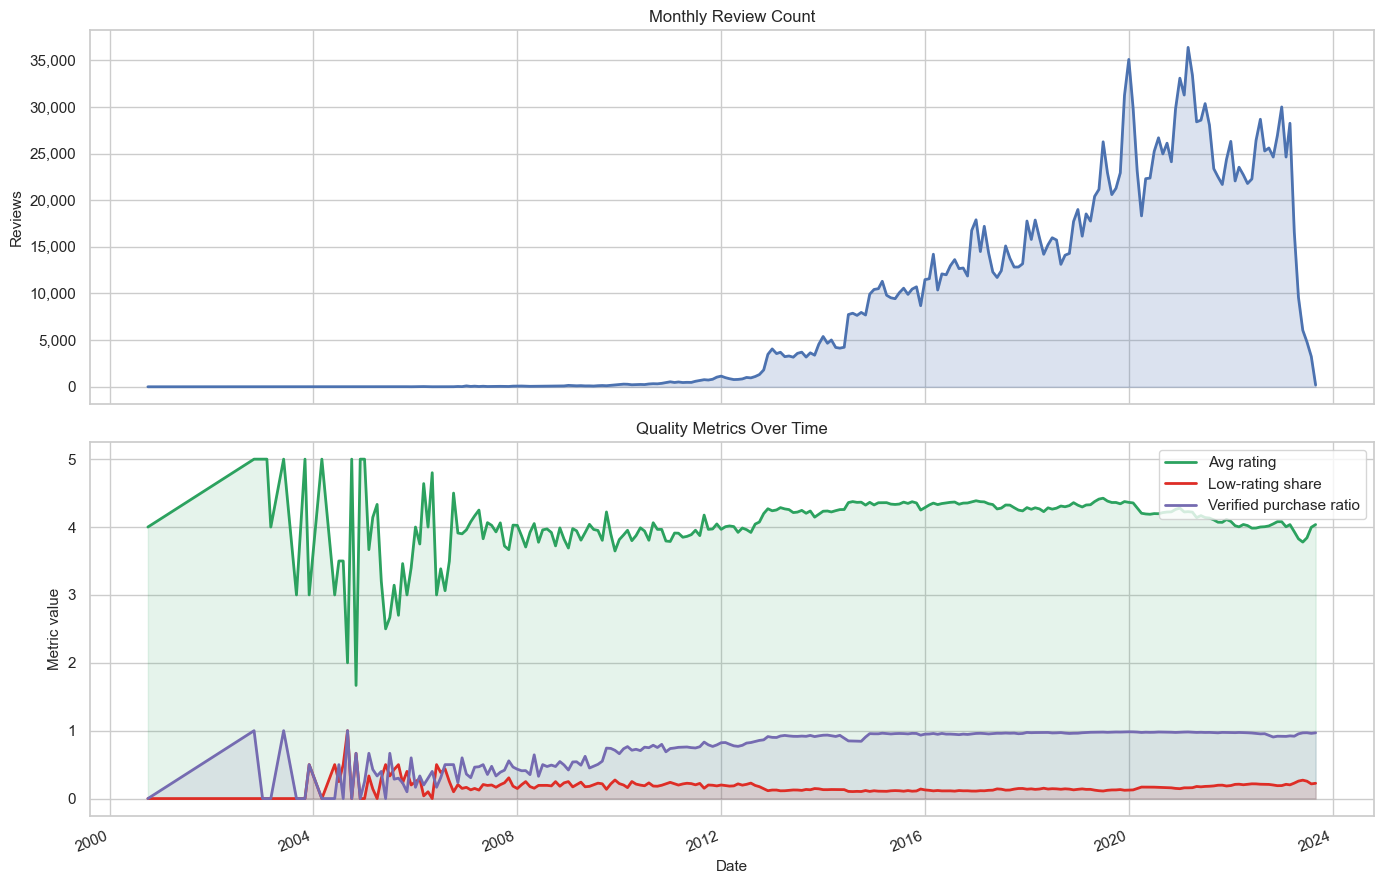

In [18]:
q2_plot = q2.copy()
q2_plot["review_date"] = pd.to_datetime(
    q2_plot["review_year"].astype(str) + "-" + q2_plot["review_month"].astype(str).str.zfill(2) + "-01"
)
q2_plot = q2_plot.sort_values("review_date")

metrics_raw = pd.DataFrame(
    {
        "Avg rating": q2_plot["avg_rating"],
        "Low-rating share": q2_plot["low_rating_share"],
        "Verified purchase ratio": q2_plot["verified_purchase_ratio"],
    }
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(q2_plot["review_date"], q2_plot["review_count"], color="#4C72B0", linewidth=2)
axes[0].fill_between(
    q2_plot["review_date"],
    q2_plot["review_count"],
    color="#4C72B0",
    alpha=0.20,
)
axes[0].set_title("Monthly Review Count")
axes[0].set_xlabel("")
axes[0].set_ylabel("Reviews")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:,.0f}"))

colors = {"Avg rating": "#2ca25f", "Low-rating share": "#de2d26", "Verified purchase ratio": "#756bb1"}
for col_name, color in colors.items():
    axes[1].plot(
        q2_plot["review_date"],
        metrics_raw[col_name],
        label=col_name,
        color=color,
        linewidth=2,
    )
    axes[1].fill_between(q2_plot["review_date"], metrics_raw[col_name], color=color, alpha=0.12)

axes[1].set_title("Quality Metrics Over Time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Metric value")
axes[1].legend(loc="upper right", frameon=True)

fig.autofmt_xdate(rotation=22)
plt.tight_layout()
plt.show()


#### Q2 — Interpretation from this export

**What the time series shows**

- **`review_count`** reaches its maximum in this file in **2021-03** (**36,377** reviews). Through **2022**, many months land in the **mid-20 thousands** per month.
- **2023** shows **large monthly drops** after winter (**Apr ~16.6k**, **May ~9.6k**, **Jun ~6.1k**, **Jul ~4.8k**, **Aug ~3.2k**, **Sep 191**). The plunge is largely **incomplete trailing months / export cutoff**, not proof of a collapse in demand by itself.
- On the **lower** panel (three raw series on one linear **y** axis), **`avg_rating`** sits near **~4.0** when monthly volume is still high in early **2023**. **`low_rating_share`** climbs toward roughly **0.21--0.27** in **Apr--Jun 2023** while **`verified_purchase_ratio`** stays **high (~0.92--0.97)**. Treat **late 2023** points as **low sample size** (**Sep** has **191** reviews).

**What the business can take from it**

Staff campaigns and support using **2021--2022** complete months as the stable baseline. Before acting on any **mid-2023** dip in stars or rise in **`low_rating_share`**, reconcile with **data completeness**. Keep interpreting the lower panel **one metric at a time** (shared axis compresses the two ratio lines visually).


### Q3. Stores with the Highest Risk Profile

**How to read the chart**

- **Horizontal bar chart**: each **bar** is a **`store`** (seller/storefront identifier from metadata). **Bar length** (x-axis) is **`low_rating_share`** — share of reviews with rating ≤ 2 among reviews attributed to that store in the Stage 2 aggregation. **Rows are ordered** by this metric (top **15** highest shares). SQL typically enforces a minimum **`review_count`** so thin bars are not purely noise.

**Axis**: x-axis uses a **percentage** scale from zero for intuitive comparison.


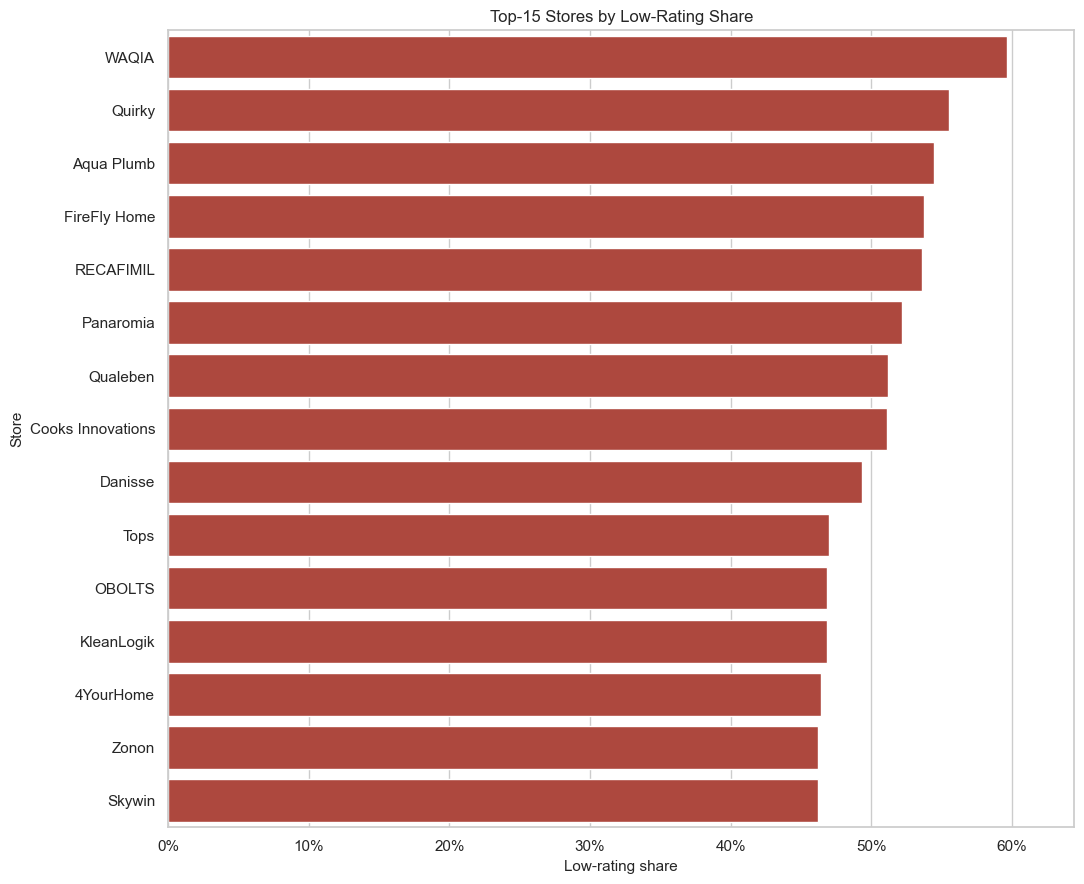

,store,review_count,avg_rating,low_rating_share,avg_helpful_vote
0,WAQIA,233,2.5236,0.5966,4.1202
1,Quirky,499,2.5952,0.5551,18.3327
2,Aqua Plumb,694,2.5965,0.5447,0.3890
3,FireFly Home,556,2.6367,0.5378,0.5953
4,RECAFIMIL,425,2.7435,0.5365,1.7412
5,Panaromia,226,2.8142,0.5221,0.7920
6,Qualeben,211,2.9479,0.5118,1.1374
7,Cooks Innovations,356,2.7388,0.5112,1.6348
8,Danisse,365,2.8575,0.4932,3.1507
9,Tops,966,2.9886,0.4700,0.4576


In [19]:
q3_plot = q3.sort_values("low_rating_share", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 9))
sns.barplot(
    data=q3_plot,
    x="low_rating_share",
    y="store",
    color="#c0392b",
    ax=ax,
)
ax.set_title("Top-15 Stores by Low-Rating Share")
ax.set_xlabel("Low-rating share")
ax.set_ylabel("Store")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
xmax = float(q3_plot["low_rating_share"].max())
ax.set_xlim(0, max(xmax * 1.08, 0.01))
plt.tight_layout()
plt.show()

display(q3_plot[["store", "review_count", "avg_rating", "low_rating_share", "avg_helpful_vote"]])

#### Q3 — Interpretation from this export

**What the bar chart shows**

Bars order stores by **`low_rating_share`** among reviews attributed to that store. **WAQIA** is longest (**~0.597**, **233** reviews; **`avg_rating` ~2.52**). **Quirky** follows (**~0.555**, **499** reviews). **Aqua Plumb**, **FireFly Home**, and **RECAFIMIL** remain above **~0.53** with low headline ratings (**~2.6--2.7**).

Notably **Quirky** combines high negativity with very high **`avg_helpful_vote`** (**~18.3**) in this extract---critical feedback attracts visibility.

**What the business can take from it**

Escalate seller governance / audits for the **top five** storefronts by **`low_rating_share`**. Prioritise **Quirky** for reputational handling (high helpful votes amplify negatives). Use **`review_count`** from the printed table to avoid over-weighting tiny sellers beyond this headline list.


### Q4. Price Band vs Rating Quality

**How to read the charts**

**Upper panel — volume**

- **x-axis**: **`price_band`** — product price bucket from metadata (`0_25`, `25_75`, …, `unknown`).
- **y-axis**: **`review_count`** — how many reviews fall in each band (demand / exposure proxy).

**Lower panel — quality**

- **Same price-band order** on the **x-axis**.
- **Green line with circles**: **`avg_rating`** (scale **1–5**, left **y-axis**).
- **Red line with squares**: **`low_rating_share`** on the **right y-axis** (0–100%), so rating and dissatisfaction share are **not forced onto one scale**.

Read **volume** separately from **quality**: a band can be high-volume but healthy, or low-volume but risky.


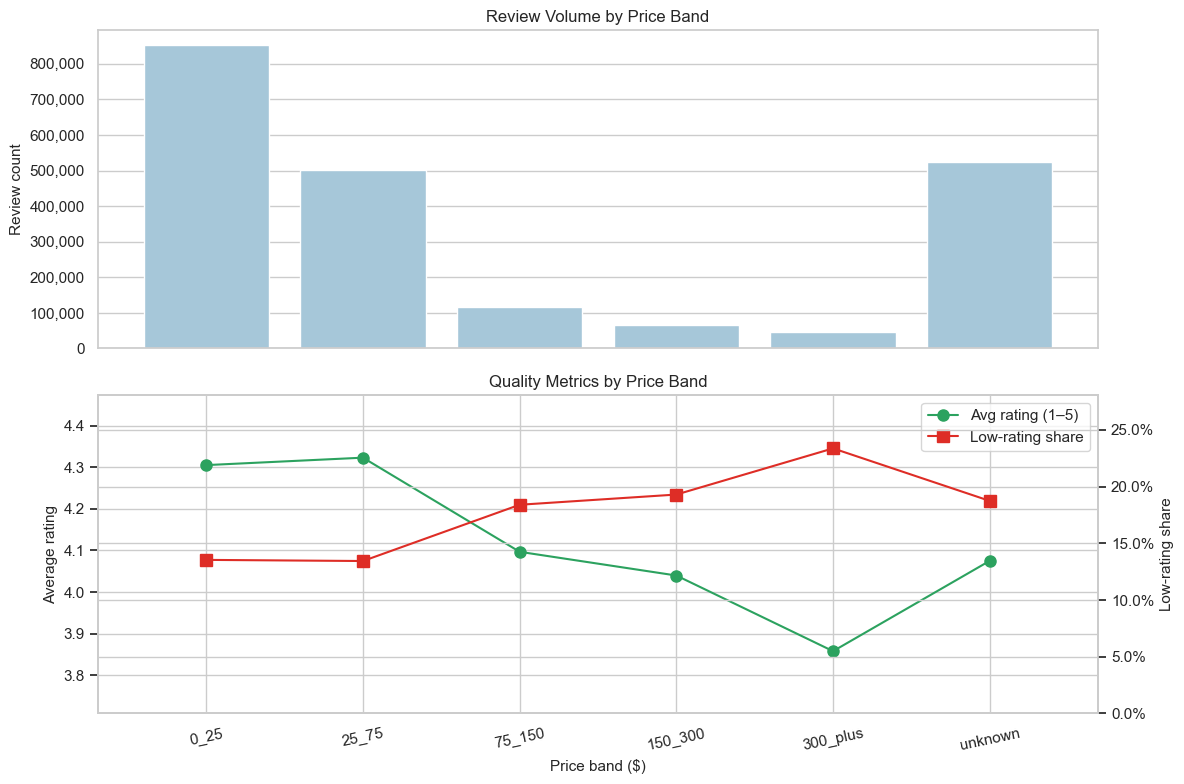

In [20]:
price_order = ["0_25", "25_75", "75_150", "150_300", "300_plus", "unknown"]
q4_plot = q4.copy()
q4_plot["price_band"] = pd.Categorical(q4_plot["price_band"], categories=price_order, ordered=True)
q4_plot = q4_plot.sort_values("price_band")

fig, (ax_vol, ax_met) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.barplot(data=q4_plot, x="price_band", y="review_count", color="#9ecae1", ax=ax_vol)
ax_vol.set_title("Review Volume by Price Band")
ax_vol.set_ylabel("Review count")
ax_vol.set_xlabel("")
ax_vol.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:,.0f}"))

ax_r = ax_met.twinx()
(ln1,) = ax_met.plot(
    range(len(q4_plot)),
    q4_plot["avg_rating"].values,
    marker="o",
    markersize=8,
    color="#2ca25f",
    label="Avg rating (1–5)",
)
(ln2,) = ax_r.plot(
    range(len(q4_plot)),
    q4_plot["low_rating_share"].values,
    marker="s",
    markersize=8,
    color="#de2d26",
    label="Low-rating share",
)
ax_met.set_xticks(range(len(q4_plot)))
ax_met.set_xticklabels(q4_plot["price_band"].astype(str), rotation=12)
ax_met.set_title("Quality Metrics by Price Band")
ax_met.set_xlabel("Price band ($)")
ax_met.set_ylabel("Average rating")
ymin = float(q4_plot["avg_rating"].min())
ymax = float(q4_plot["avg_rating"].max())
pad = max(0.15, (ymax - ymin) * 0.15)
ax_met.set_ylim(max(1.0, ymin - pad), min(5.0, ymax + pad))
ax_r.set_ylabel("Low-rating share")
ax_r.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ls_max = float(q4_plot["low_rating_share"].max())
ax_r.set_ylim(0, max(ls_max * 1.2, 0.05))
ax_met.legend(handles=[ln1, ln2], labels=[ln1.get_label(), ln2.get_label()], loc="upper right")

plt.tight_layout()
plt.show()

#### Q4 — Interpretation from this export

**What the charts show**

**Volume**

Most reviews fall in **`0_25`** (**851,510**) and **`25_75`** (**500,803**); **`unknown`** price is also large (**522,690**).

**Quality by `price_band`**

- **`0_25`** and **`25_75`** show the **strongest sentiment**: **`avg_rating`** about **4.31** and **`low_rating_share`** about **0.134--0.135**.
- **`75_150`** and **`150_300`** sit between (**`avg_rating` ~4.04--4.10**, **`low_rating_share` ~0.18--0.19**).
- **`300_plus`** is the weakest band here: **`avg_rating` ~3.86**, **`low_rating_share` ~0.234** (**46,025** reviews).

**What the business can take from it**

Budget bands look comparatively healthy on stars in this slice; **premium** (**`300_plus`**) underperforms---prioritise **value-for-money narrative**, specs accuracy, and post-sale support for expensive SKUs. Mid bands merit targeted monitoring (**~0.18--0.19** **`low_rating_share`**) without assuming catalogue-wide failure.


### Q5. Helpfulness of Negative Feedback by Category

**How to read the chart**

- **Scatter plot**: each **point** is a **`main_category`** (top **20** by **`review_count`** in this slice).
- **x-axis**: **`low_rating_share`** — fraction of reviews that are 1–2 stars for that category (percentage scale).
- **y-axis**: **`avg_helpful_on_low_ratings`** — average number of “helpful” votes on **low-rating** reviews for that category (engagement with negative content).
- **Point size** encodes **`review_count`** (larger points = more reviews). **Colour** distinguishes **`main_category`**.

Useful pattern: categories **high on the x-axis** carry more severe negativity; **high on the y-axis** mean readers find critical reviews more useful there.


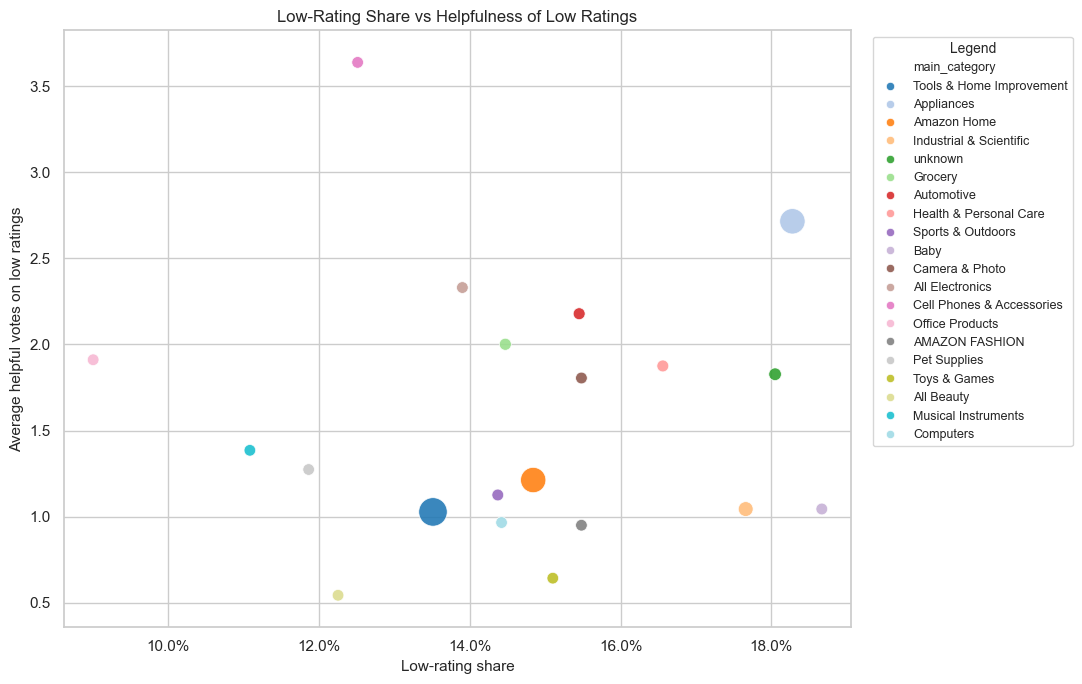

,main_category,review_count,low_rating_share,low_rating_helpful_votes,avg_helpful_on_low_ratings
1,Tools & Home Improvement,771841,0.1351,107198,1.0281
0,Appliances,582120,0.1828,288867,2.7150
2,Amazon Home,575362,0.1484,103581,1.2132
3,Industrial & Scientific,97442,0.1766,17973,1.0447
4,unknown,28172,0.1805,9290,1.8273
5,Grocery,11751,0.1447,3402,2.0012
6,Automotive,8407,0.1545,2830,2.1786
7,Health & Personal Care,7462,0.1656,2318,1.8754
10,Sports & Outdoors,4676,0.1437,757,1.1265
11,Baby,3803,0.1867,742,1.0451


In [21]:
q5_plot = q5.sort_values("review_count", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    data=q5_plot,
    x="low_rating_share",
    y="avg_helpful_on_low_ratings",
    size="review_count",
    sizes=(70, 420),
    hue="main_category",
    palette="tab20",
    alpha=0.88,
    edgecolor="white",
    linewidth=0.55,
    legend="brief",
    ax=ax,
)

ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
xr = q5_plot["low_rating_share"]
yr = q5_plot["avg_helpful_on_low_ratings"]
pad_x = 0.04 * (xr.max() - xr.min() + 1e-12)
pad_y = 0.06 * (yr.max() - yr.min() + 1e-12)
ax.set_xlim(max(0.0, float(xr.min()) - pad_x), min(1.0, float(xr.max()) + pad_x))
ax.set_ylim(max(0.0, float(yr.min()) - pad_y), float(yr.max()) + pad_y)

handles, labels = ax.get_legend_handles_labels()
filtered = []
i = 0
while i < len(labels):
    lab = labels[i]
    if lab == "review_count":
        i += 1
        while i < len(labels) and labels[i].replace(".", "", 1).isdigit():
            i += 1
        continue
    filtered.append((handles[i], labels[i]))
    i += 1
if filtered:
    fh, fl = zip(*filtered)
    ax.legend(
        fh,
        fl,
        title="Legend",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True,
        fontsize=9,
        title_fontsize=10,
    )

ax.set_title("Low-Rating Share vs Helpfulness of Low Ratings")
ax.set_xlabel("Low-rating share")
ax.set_ylabel("Average helpful votes on low ratings")

plt.tight_layout()
plt.show()

display(
    q5_plot[
        [
            "main_category",
            "review_count",
            "low_rating_share",
            "low_rating_helpful_votes",
            "avg_helpful_on_low_ratings",
        ]
    ]
)

#### Q5 — Interpretation from this export (top 20 categories by volume)

**What the scatter shows**

Among the **largest** categories by **`review_count`**:

- **Tools & Home Improvement** (**~772k** reviews) combines huge volume with a relatively **moderate `low_rating_share` (~0.135)**.
- **Appliances** (**~582k**) carries a **higher `low_rating_share` (~0.183)** and the **highest `avg_helpful_on_low_ratings` (~2.72)** among these heavyweights---negative reviews frequently earn helpful votes.
- **Cell Phones & Accessories** is **smaller (~2.1k)** but **`avg_helpful_on_low_ratings` peaks (~3.64)** while **`low_rating_share` stays lower (~0.125)**---few bad reviews, but they resonate when they appear.
- **Office Products** sits **furthest left** on **`low_rating_share` (~0.09)** in this top-20 slice.

**What the business can take from it**

Invest remediation effort in **Appliances** negatives that already attract helpful votes (visible defects). Treat **Cell Phones** as high-salience even at smaller **n**. Keep **Tools** on steady monitoring: volume is massive but **`low_rating_share`** is comparatively contained at scale.


## Notes

- This notebook is intentionally exploratory and does not modify pipeline outputs.
- All insights rely on Stage 2 exported CSV snapshots.
- If `q*.csv` are regenerated, rerun all cells to refresh plots.